In [28]:
import pandas as pd
import numpy as np
from scipy.stats import hypergeom, multinomial
import matplotlib.pyplot as plt
from empiricaldist import Pmf

In [33]:

def normalize(joint):
    """Normalize the joint distribution."""
    prob_data = joint.to_numpy().sum()
    joint /= prob_data
    return prob_data

def make_joint(pmf1, pmf2):
    """Make a joint distribution from two PMFs."""
    X, Y = np.meshgrid(pmf1, pmf2)
    return pd.DataFrame(X * Y, columns=pmf1.qs, index=pmf2.qs)

def make_uniform(qs, name=None, **options):
    """Make a uniform PMF."""
    pmf = Pmf(1.0, qs, **options)
    pmf.normalize()
    if name:
        pmf.index.name = name
    return pmf

def plot_contour(joint):
    '''plot a joint distribution as a contour plot.'''
    plt.contour(joint.columns, joint.index, joint, cmap='viridis')

In [3]:
N = 100
K = 23
n = 19

In [4]:
ks = np.arange(12)
ps = hypergeom(N, K, n).pmf(ks)

In [5]:
qs = np.arange(50, 501)
prior_N = make_uniform(qs, name='N')
prior_N.shape

(451,)

In [6]:
Ns = prior_N.qs
K = 23
n = 19
k = 4

In [7]:
likelihood = hypergeom(Ns, K, n).pmf(k)

posterior_N = likelihood * prior_N
posterior_N.normalize()

np.float64(0.07755224277106798)

<Axes: xlabel='N'>

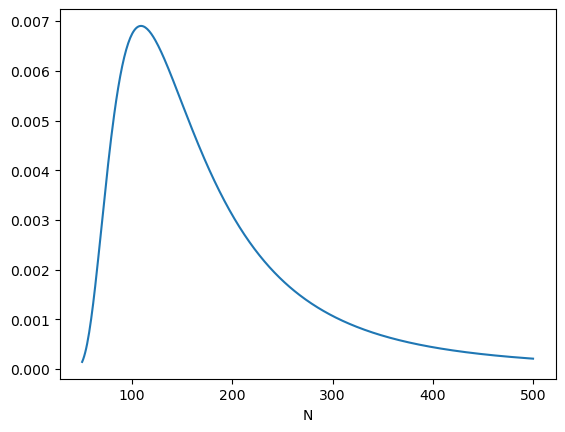

In [8]:
posterior_N.plot()

In [9]:
posterior_N.max_prob()

np.int64(109)

In [10]:
posterior_N.mean()

np.float64(173.79880627085805)

In [11]:
posterior_N.credible_interval(0.9)

array([ 77., 363.])

In [12]:
k10 = 23 - 4
k01 = 19-4
k11 = 4

In [13]:
N = 100

observed = k01 + k10+ k11
k00 = N - observed
k00

62

In [14]:
qs = np.linspace(0, 0.99, num=100)
prior_p = make_uniform(qs, name='p')

In [22]:
joint_prior = make_joint(prior_p, prior_N)

In [23]:
joint_pmf = Pmf(joint_prior.stack())
joint_pmf.head(3)

50  0.00    0.000022
    0.01    0.000022
    0.02    0.000022
dtype: float64

In [24]:
likelihood = joint_pmf.copy()

In [30]:
for N, p in joint_pmf.index:
    k00 = N - observed
    x = [k00, k01, k10, k11]
    q = 1-p
    y = [q*q, q*p, p*q, p*p]
    likelihood[N, p] = multinomial.pmf(x, N, y)

In [31]:
poster_pmf = joint_pmf * likelihood
poster_pmf.normalize()

np.float64(2.9678796190279555e-05)

In [32]:
joint_posterior = poster_pmf.unstack()

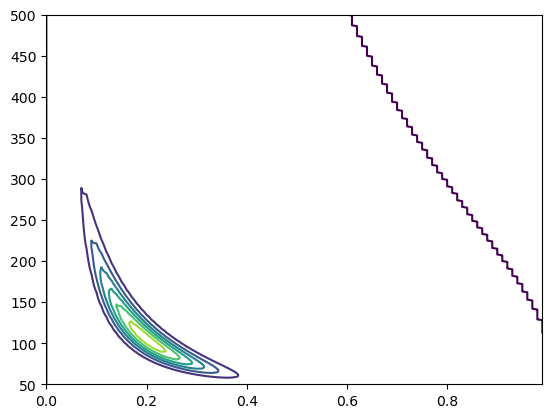

In [34]:
plot_contour(joint_posterior)